In [70]:
#for multiclass classification
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

NUM_CLASS=4
NUM_FEATURES=2
SAMPLE=1000
RANDOM_SEED=42

x_blob , y_blob = make_blobs(n_samples=SAMPLE , n_features=NUM_FEATURES , centers=NUM_CLASS , cluster_std=1.5 , random_state=RANDOM_SEED)
x_blob  = torch.tensor(x_blob)
y_blob = torch.tensor(y_blob)
x_blob

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        ...,
        [ 3.2158,  5.9217],
        [-7.7939, -7.1606],
        [-9.6816,  7.0097]], dtype=torch.float64)

In [71]:
from sklearn.model_selection import train_test_split
x_blob_train , x_blob_test , y_blob_train , y_blob_test = train_test_split(x_blob , y_blob , test_size=0.2 , random_state=RANDOM_SEED)
len(x_blob_test) , len(y_blob_test)
x_blob_test

tensor([[  4.6675,   4.4878],
        [ -7.9969,   6.8803],
        [ -6.2801,  -7.8571],
        [  3.6833,   1.1767],
        [ -0.1404,  10.1654],
        [ -9.7570,   7.8658],
        [ -4.4295,  -8.5996],
        [ -2.1731,   9.0332],
        [ -9.2145,  -7.5223],
        [ -1.4015,   9.2713],
        [ -3.2043,   8.3157],
        [  5.6627,   4.7432],
        [ -0.7720,  10.2018],
        [ -2.0123,  10.4776],
        [ -1.7302,  11.3134],
        [ -6.7496,   6.9485],
        [ -8.3306,   6.8804],
        [ -5.4338,  -3.5643],
        [ -8.5540,   8.8251],
        [ -8.7147,   5.1372],
        [ -7.0068,   8.1967],
        [ -2.1881,   7.1457],
        [  0.9324,   0.7778],
        [ -4.2757,  -6.5832],
        [ -4.6285,  -5.6048],
        [ -8.0851,  -4.4214],
        [-10.0527,   7.9596],
        [ -0.3325,  10.4532],
        [  4.0984,   3.7122],
        [ -3.3258,   9.1807],
        [ -7.3375,   6.3176],
        [  4.5657,   2.9854],
        [  4.0945,   1.8878],
        [-

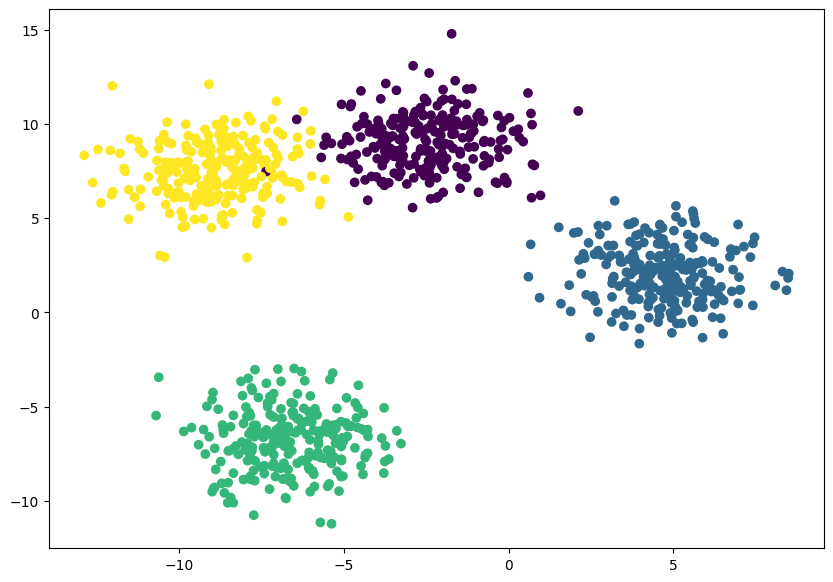

In [72]:

plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0] , x_blob[:,1] , c=y_blob)


In [73]:
#creating the model
import torch
from torch import nn
class BlobModelv1(nn.Module):
  def __init__(self , input_features , output_features , hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
          nn.Linear(in_features=input_features , out_features=hidden_units),
          #adding non linearity
          # nn.ReLU(),
          nn.Linear(in_features=hidden_units , out_features=hidden_units),
          # nn.ReLU(),
          nn.Linear(in_features=hidden_units , out_features=output_features),

    )

  def forward(self , x):
    return self.linear_layer_stack(x)

# model0 = BlobModelv1(x , y ). to(device)

In [74]:
#loss function and optimizer
loss = nn.CrossEntropyLoss()
model0 = BlobModelv1(input_features=NUM_FEATURES , output_features=NUM_CLASS)
optimizer = torch.optim.SGD(params=model0.parameters() , lr=0.1)

In [75]:
y_logits_train = model0(x_blob_train.type(torch.float))
y_pred_labels_train = torch.argmax(y_logits_train, dim=1)

def accuracy(y_preds , y_true):
  correct = torch.eq(y_preds , y_true).sum().item()
  acc = (correct / len(y_preds)) *100
  return acc
# Calculate training accuracy
accuracy_train = (y_pred_labels_train == y_blob_train).float().mean()
print(f"Training Accuracy: {accuracy_train.item():.4f}")

Training Accuracy: 0.6550


In [76]:
# Make predictions with the model in inference mode
model0.eval() # set model to evaluation mode
with torch.inference_mode(): # turn on inference_mode
    y_logits_test = model0(x_blob_test.type(torch.float))
    y_preds_test = torch.argmax(y_logits_test, dim=1)


print(f"Test Predictions (first 5): {y_preds_test[:5]}")
print(f"True Test Labels (first 5): {y_blob_test[:5]}")

Test Predictions (first 5): tensor([3, 3, 2, 1, 3])
True Test Labels (first 5): tensor([1, 3, 2, 1, 0])


In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100
print(f"Using device: {device}")

# Move model to device
model0.to(device)

x_blob_train = x_blob_train.to(device).type(torch.float)
y_blob_train = y_blob_train.to(device).type(torch.long) # Changed to torch.long
x_blob_test = x_blob_test.to(device).type(torch.float)
y_blob_test = y_blob_test.to(device).type(torch.long) # Changed to torch.long

for epoch in range(epochs):
  model0.train()
  y_logits=model0(x_blob_train)
  train_loss = loss(y_logits , y_blob_train) # Use train_loss instead of overwriting loss
  y_pred_labels_train = torch.argmax(y_logits, dim=1) # Get predicted labels
  train_accuracy = accuracy(y_pred_labels_train , y_blob_train) # Use predicted labels for accuracy
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model0.eval()
  with torch.inference_mode():
    test_logits = model0(x_blob_test)
    test_loss = loss(test_logits , y_blob_test) # Use test_loss
    y_pred_labels_test = torch.argmax(test_logits, dim=1) # Get predicted labels
    test_accuracy = accuracy(y_pred_labels_test , y_blob_test) # Use predicted labels for accuracy

  if epoch % 10 == 0: # Corrected SyntaxError
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

Using device: cuda
Epoch: 0 | Train Loss: 1.0432 | Train Acc: 65.50% | Test Loss: 0.5786 | Test Acc: 95.50%
Epoch: 10 | Train Loss: 0.1440 | Train Acc: 99.12% | Test Loss: 0.1304 | Test Acc: 99.00%
Epoch: 20 | Train Loss: 0.0806 | Train Acc: 99.12% | Test Loss: 0.0722 | Test Acc: 99.50%
Epoch: 30 | Train Loss: 0.0592 | Train Acc: 99.12% | Test Loss: 0.0513 | Test Acc: 99.50%
Epoch: 40 | Train Loss: 0.0489 | Train Acc: 99.00% | Test Loss: 0.0410 | Test Acc: 99.50%
Epoch: 50 | Train Loss: 0.0429 | Train Acc: 99.00% | Test Loss: 0.0349 | Test Acc: 99.50%
Epoch: 60 | Train Loss: 0.0391 | Train Acc: 99.00% | Test Loss: 0.0308 | Test Acc: 99.50%
Epoch: 70 | Train Loss: 0.0364 | Train Acc: 99.00% | Test Loss: 0.0280 | Test Acc: 99.50%
Epoch: 80 | Train Loss: 0.0345 | Train Acc: 99.00% | Test Loss: 0.0259 | Test Acc: 99.50%
Epoch: 90 | Train Loss: 0.0330 | Train Acc: 99.12% | Test Loss: 0.0242 | Test Acc: 99.50%


In [78]:
#evaluating  the predictions
model0.eval()
with torch.inference_mode():
  y_logits_test = model0(x_blob_test.type(torch.float))
  # y_pred_test = torch.softmax(y_logits , dim=1)
  y_preds_test =torch.argmax(y_logits_test , dim=1)
  # loss = nn.CrossEntropyLoss()
  test_loss = loss(y_logits_test , y_blob_test)
  accuracy = accuracy(y_preds_test , y_blob_test)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.0230 | Test Accuracy: 99.50%


In [79]:
import numpy as np

def plot_decision_boundary(model, X, y):
    # Move data to CPU if on GPU
    X = X.cpu().numpy()
    y = y.cpu().numpy()

    # Setup prediction boundaries and make predictions over 10,000 points (TENSORFLOW STYLE)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Make features float
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Move data to the same device as model
    model.eval()
    with torch.inference_mode():
        X_to_predict_on = X_to_predict_on.to(next(model.parameters()).device)
        y_logits = model(X_to_predict_on)

    # Change predictions to labels (these are on the GPU, so will need to be moved to CPU for plotting)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1).cpu().numpy()

    # Reshape prediction data into a grid
    y_pred = y_pred.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

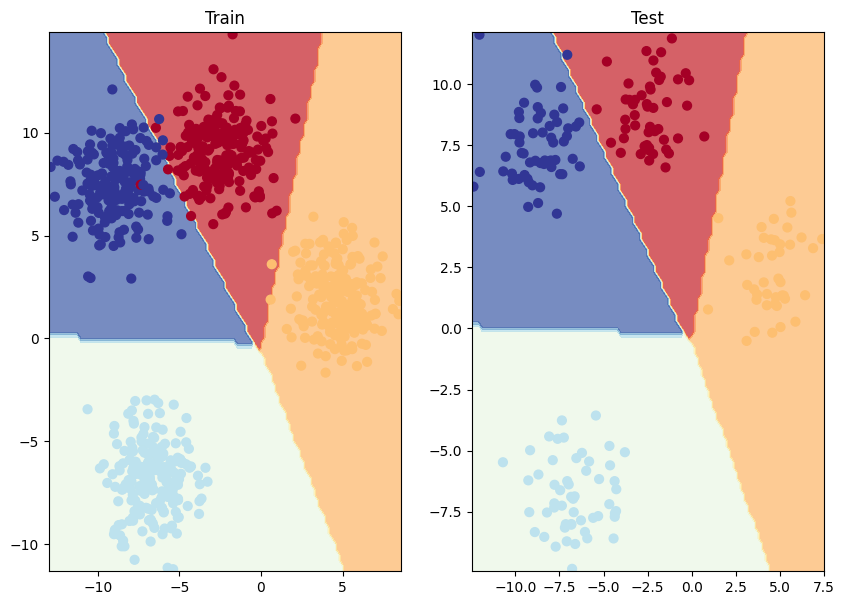

In [80]:
plt.figure(figsize=(10 , 7))
plt.subplot(1 , 2 ,1)
plt.title("Train")
plot_decision_boundary(model0 , x_blob_train , y_blob_train)
plt.subplot(1 , 2 ,2)
plt.title("Test")
plot_decision_boundary(model0 , x_blob_test , y_blob_test)